<a href="https://colab.research.google.com/github/nayyen/PraktikClustering-NaylaHana-FSD/blob/main/praktik_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktik Clustering - Fundamen Sains Data
**Anggota Kelompok:**

1.   Nayla Raihaanah Nabilah Hakim(24523010)
2.   Raihana Salwa Hafizhah (24523072)



## Deskripsi Dataset
Dataset yang digunakan adalah **Mall Customers Dataset** yang di ambil dari https://www.kaggle.com/datasets/kandij/mall-customers .

Dataset ini berisi data pelanggan sebuah mall yang mencakup:
* **CustomerID**: ID unik pelanggan.
* **Gender**: Jenis kelamin pelanggan.
* **Age**: Usia pelanggan.
* **Annual Income (k$)**: Pendapatan tahunan pelanggan (dalam ribuan dollar).
* **Spending Score (1-100)**: Skor pengeluaran pelanggan yang ditentukan oleh pihak mall berdasarkan perilaku belanja.

Kita akan menggunakan dua variabel utama:
* **Annual Income (k$)**: Pendapatan tahunan pelanggan.
* **Spending Score (1-100)**: Skor perilaku belanja.

Tujuannya adalah mengelompokkan pelanggan agar mall bisa memberikan promo yang lebih tepat sasaran.


**Import Library**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# Load dataset
df = pd.read_csv('Mall_Customers.csv')

# Menampilkan 5 data teratas
print(df.head())

# Memilih fitur untuk clustering (Annual Income dan Spending Score)
X = df.iloc[:, [3, 4]].values


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


## Preprocessing Data

## Feature Scaling
Karena K-Means, Hierarchical, dan DBSCAN berbasis pada jarak (distance-based), kita harus menyamakan skala datanya agar satu variabel tidak mendominasi variabel lainnya.

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data berhasil di-scale.")

Data berhasil di-scale.


## Evaluasi Penentuan Jumlah Cluster

Sebelum menjalankan algoritma, kita perlu menentukan jumlah cluster ($k$) yang paling optimal agar hasil pengelompokan akurat.

* **Elbow Method**: Digunakan untuk menentukan jumlah cluster dengan melihat titik "siku" pada grafik *Within-Cluster Sum of Square* (WCSS). Titik di mana penurunan WCSS mulai melandai adalah jumlah cluster terbaik.
* **Silhouette Score**: Digunakan untuk memvalidasi seberapa baik setiap objek telah dikelompokkan. Nilai yang mendekati **1** menunjukkan bahwa objek berada di cluster yang tepat dan jauh dari cluster tetangga.

## 1. K-Means Clustering
Algoritma ini mengelompokkan data ke dalam sejumlah 'k' cluster berdasarkan jarak ke centroid. Kita akan menggunakan **Elbow Method** untuk menentukan jumlah cluster optimal.

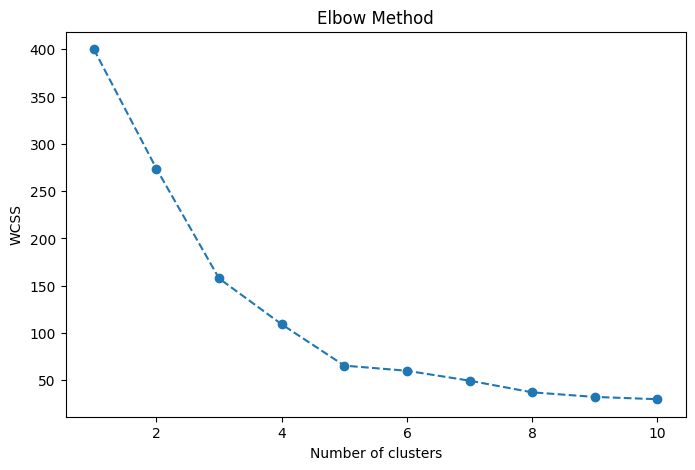

Silhouette Score K-Means: 0.5547


In [8]:
# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Berdasarkan grafik, siku (elbow) terlihat di k=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Evaluasi Silhouette Score
print(f'Silhouette Score K-Means: {silhouette_score(X_scaled, y_kmeans):.4f}')

## 2. Hierarchical Clustering
Menggunakan metode **Agglomerative** (bottom-up). Kita akan melihat struktur cluster melalui **Dendrogram**.

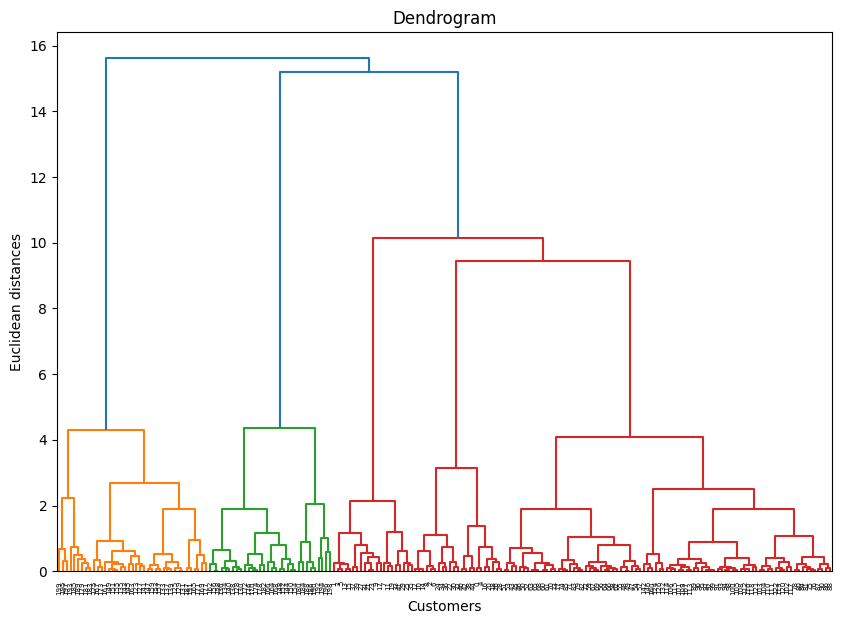

Silhouette Score Hierarchical: 0.5538


In [9]:
# Membuat Dendrogram
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

# Menjalankan Agglomerative Clustering (k=5 berdasarkan hasil dendrogram)
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)

# Evaluasi Silhouette Score
print(f'Silhouette Score Hierarchical: {silhouette_score(X_scaled, y_hc):.4f}')

## 3. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
Berbeda dengan dua algoritma sebelumnya, DBSCAN mencari area yang padat dan bisa mendeteksi **outlier** (noise).

In [10]:
# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5) # eps disesuaikan setelah scaling
y_dbscan = dbscan.fit_predict(X_scaled)

# Hitung Silhouette Score (Hanya untuk data yang bukan noise/ -1)
mask = y_dbscan != -1
if len(set(y_dbscan[mask])) > 1:
    score = silhouette_score(X_scaled[mask], y_dbscan[mask])
    print(f'Silhouette Score DBSCAN (tanpa noise): {score:.4f}')
else:
    print("DBSCAN hanya menemukan 1 cluster, coba kecilkan nilai eps.")

Silhouette Score DBSCAN: 0.4368


## Visualisasi Hasil Clustering
Berikut adalah perbandingan hasil pengelompokan dari ketiga algoritma tersebut.

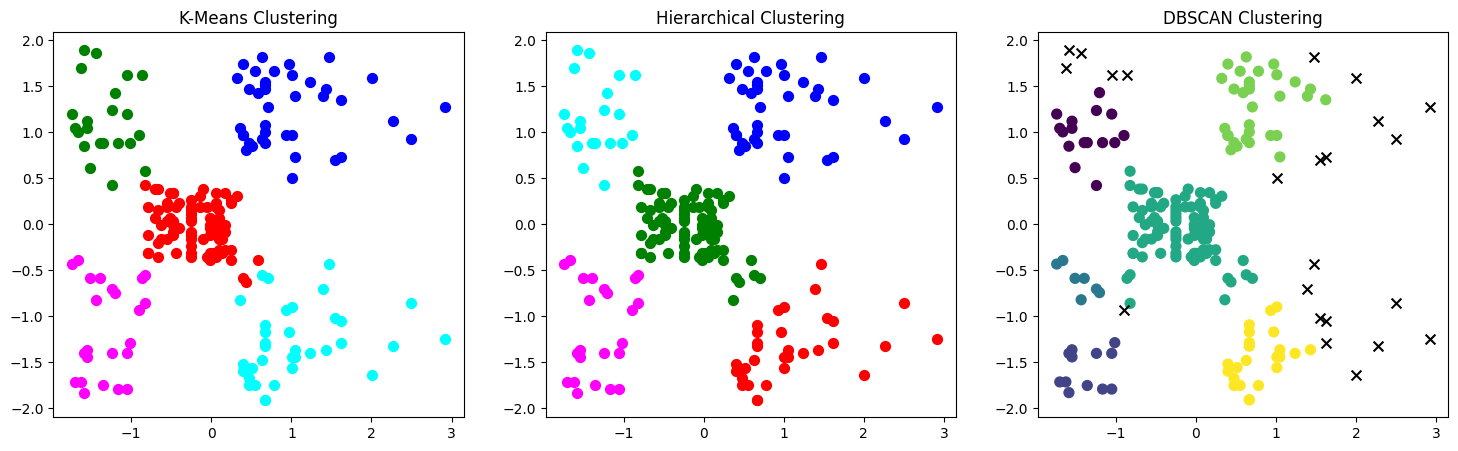

In [11]:
plt.figure(figsize=(18, 5))

# Plot K-Means
plt.subplot(1, 3, 1)
plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], s=50, c='red', label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], s=50, c='blue', label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], s=50, c='green', label='Cluster 3')
plt.scatter(X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1], s=50, c='cyan', label='Cluster 4')
plt.scatter(X_scaled[y_kmeans == 4, 0], X_scaled[y_kmeans == 4, 1], s=50, c='magenta', label='Cluster 5')
plt.title('K-Means Clustering')

# Plot Hierarchical
plt.subplot(1, 3, 2)
plt.scatter(X_scaled[y_hc == 0, 0], X_scaled[y_hc == 0, 1], s=50, c='red')
plt.scatter(X_scaled[y_hc == 1, 0], X_scaled[y_hc == 1, 1], s=50, c='blue')
plt.scatter(X_scaled[y_hc == 2, 0], X_scaled[y_hc == 2, 1], s=50, c='green')
plt.scatter(X_scaled[y_hc == 3, 0], X_scaled[y_hc == 3, 1], s=50, c='cyan')
plt.scatter(X_scaled[y_hc == 4, 0], X_scaled[y_hc == 4, 1], s=50, c='magenta')
plt.title('Hierarchical Clustering')

# Plot DBSCAN
plt.subplot(1, 3, 3)
plt.scatter(X_scaled[y_dbscan != -1, 0], X_scaled[y_dbscan != -1, 1], c=y_dbscan[y_dbscan != -1], cmap='viridis', s=50)
plt.scatter(X_scaled[y_dbscan == -1, 0], X_scaled[y_dbscan == -1, 1], c='black', marker='x', s=50, label='Noise')
plt.title('DBSCAN Clustering')

plt.show()

## Analisis Hasil Clustering
Berdasarkan hasil visualisasi (terutama K-Means yang paling rapi), kita bisa membagi pelanggan menjadi 5 kategori:
1. **Cluster 1 (High Income, Low Spending)**: Pelanggan "Hemat" (Duit banyak tapi jarang belanja).
2. **Cluster 2 (Average Income, Average Spending)**: Pelanggan "Standar".
3. **Cluster 3 (High Income, High Spending)**: Pelanggan "Sultan/Target Utama" (Fokus promosi barang mewah).
4. **Cluster 4 (Low Income, High Spending)**: Pelanggan "Impulsif" (Duit sedikit tapi sering belanja).
5. **Cluster 5 (Low Income, Low Spending)**: Pelanggan "Sensitif Harga".

**DBSCAN** juga mendeteksi beberapa titik hitam (noise), yang merupakan pelanggan dengan pola belanja yang sangat tidak lazim (outlier).

## Kesimpulan
1. **K-Means**: Memberikan hasil yang sangat rapi dengan 5 cluster yang terbagi berdasarkan kombinasi pendapatan rendah/tinggi dan skor pengeluaran rendah/tinggi. Ini adalah metode yang paling mudah diinterpretasikan untuk dataset ini.
2. **Hierarchical Clustering**: Memberikan hasil yang mirip dengan K-Means, mengonfirmasi bahwa pembagian menjadi 5 kelompok adalah yang paling alami bagi data ini.
3. **DBSCAN**: Sangat sensitif terhadap parameter `eps`. Keunggulannya adalah mampu mengidentifikasi titik-titik data yang dianggap "noise" (tanda silang hitam) yang tidak masuk ke kelompok manapun karena terlalu jauh dari kepadatan data utama.

**Rekomendasi Strategi:** Kelompok dengan *Annual Income* tinggi dan *Spending Score* tinggi (Cluster 'Target') harus menjadi fokus utama promosi produk eksklusif.